In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

In [2]:
df = pd.read_csv('package.csv')

In [3]:
df.head()

,CGPA,Package_LPA
0,6.87,11.49
1,9.75,19.61
2,8.66,16.94
3,7.99,14.26
4,5.78,11.32


In [4]:
df.shape

(200, 2)

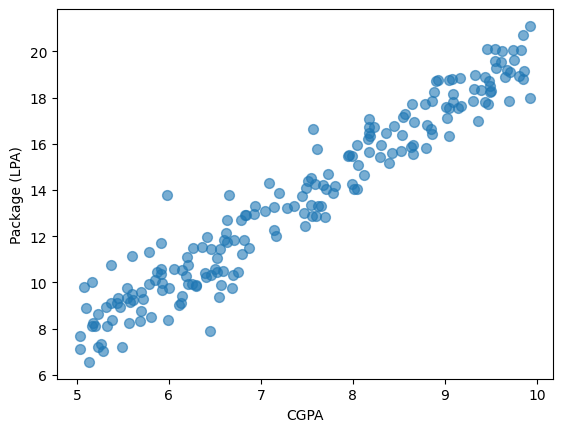

In [5]:
plt.scatter(df['CGPA'], df['Package_LPA'], alpha=0.6, s=50)
plt.xlabel('CGPA') 
plt.ylabel('Package (LPA)')
plt.show()

In [6]:
class RidgeRegression:

    def __init__(self, alpha):
        
        self.m = None
        self.b = None
        self.alpha = alpha

    def fit(self, X_train, Y_train):

        numerator = 0
        denominator = 0

        for i in range(X_train.shape[0]):
            numerator = numerator + ((Y_train[i] - Y_train.mean()) * (X_train[i] - X_train.mean()))
            denominator = denominator + ((X_train[i] - X_train.mean()) * (X_train[i] - X_train.mean()))

        self.m = numerator / (denominator +  + self.alpha)
        self.b = Y_train.mean() - (self.m * X_train.mean())
        print("slope(m) is : ", self.m)
        print("Intercept(b) is : ", self.b)

    def predict(self, X_test):
        
        y_hat = (self.m * X_test) + self.b
        return y_hat

In [7]:
X = df.iloc[:, 0:1].values
y = df.iloc[:, -1].values

In [8]:
X_train, X_test, Y_train, Y_test = train_test_split(X,y, test_size=0.2, random_state=2) 

In [9]:
model = RidgeRegression(0.5)

In [10]:
model.fit(X_train, Y_train)

slope(m) is :  [2.46907657]
Intercept(b) is :  [-4.6907914]


In [11]:
predicted_data = model.predict(X_test)

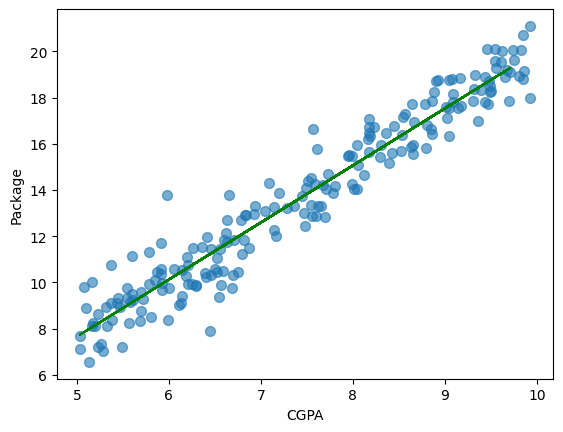

In [12]:
plt.scatter(df['CGPA'], df['Package_LPA'], alpha=0.6, s=50)
plt.plot(X_test, predicted_data, color='green')
plt.xlabel("CGPA")
plt.ylabel("Package")
plt.show()

In [13]:
acc = r2_score(Y_test, predicted_data)

In [14]:
acc

0.9275443169766081

Using sklearn

In [15]:
from sklearn.linear_model import Ridge

In [16]:
model1 = Ridge(alpha=0.9)

In [17]:
model1.fit(X_train, Y_train)

,alpha,0.9
,fit_intercept,True
,copy_X,True
,max_iter,None
,tol,0.0001
,solver,'auto'
,positive,False
,random_state,None


In [18]:
y_pred = model1.predict(X_test)

In [19]:
acc = r2_score(Y_test, y_pred)
acc

0.9274937988668948

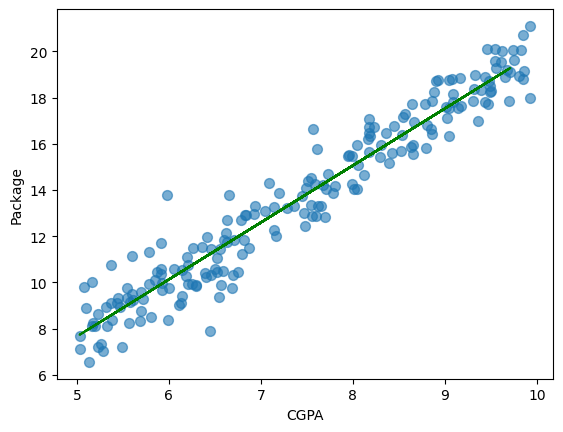

In [20]:
plt.scatter(df['CGPA'], df['Package_LPA'], alpha=0.6, s=50)
plt.plot(X_test, y_pred, color='green')
plt.xlabel("CGPA")
plt.ylabel("Package")
plt.show()